# Laboratorio: NFA a DFA

Este Notebook contiene la guía paso a paso para implementar la fase de análisis léxico de un compilador.

Primero, configuramos las clases necesarias para representar los estados y el autómata. Ejecuta esta celda para cargar el motor de generación de NFA desde una regex.

In [105]:
import graphviz
from enum import Enum

# Configuración de símbolos y tipos
EPSILON = 'ε'

class CharType(Enum):
    ALTERNATION = 0; CONCATENATION = 1; OPTIONAL = 2; POSITIVE_CLOSURE = 3
    KLEENE_STAR = 4; OPERAND = 5; L_PAREN = 6; R_PAREN = 7; EPSILON = 8

class Item:
    def __init__(self, value, char_type: CharType):
        self.value = value
        self.char_type = char_type

class Regex:
    def __init__(self, regex):
        self.items = []
        for c in regex:
            if c == '|': self.items.append(Item(c, CharType.ALTERNATION))
            elif c == '.': self.items.append(Item(c, CharType.CONCATENATION))
            elif c == '?': self.items.append(Item(c, CharType.OPTIONAL))
            elif c == '+': self.items.append(Item(c, CharType.POSITIVE_CLOSURE))
            elif c == '*': self.items.append(Item(c, CharType.KLEENE_STAR))
            elif c == '(': self.items.append(Item(c, CharType.L_PAREN))
            elif c == ')': self.items.append(Item(c, CharType.R_PAREN))
            elif c == 'ε': self.items.append(Item(c, CharType.EPSILON))
            else: self.items.append(Item(c, CharType.OPERAND))
        self.__insert_concatenation()

    def __insert_concatenation(self):
        new_items = []
        for i in range(len(self.items)):
            new_items.append(self.items[i])
            if i < len(self.items) - 1:
                if (self.items[i].char_type in [CharType.OPERAND, CharType.R_PAREN, CharType.KLEENE_STAR, CharType.POSITIVE_CLOSURE, CharType.OPTIONAL] and
                    self.items[i + 1].char_type in [CharType.OPERAND, CharType.L_PAREN]):
                    new_items.append(Item('.', CharType.CONCATENATION))
        self.items = new_items

    def to_postfix(self):
        precedence = {CharType.ALTERNATION: 1, CharType.CONCATENATION: 2, CharType.OPTIONAL: 3, CharType.POSITIVE_CLOSURE: 4, CharType.KLEENE_STAR: 5}
        output, stack = [], []
        for item in self.items:
            if item.char_type in [CharType.OPERAND, CharType.EPSILON]: output.append(item)
            elif item.char_type in precedence:
                while stack and stack[-1].char_type != CharType.L_PAREN and precedence.get(stack[-1].char_type, 0) >= precedence[item.char_type]:
                    output.append(stack.pop())
                stack.append(item)
            elif item.char_type == CharType.L_PAREN: stack.append(item)
            elif item.char_type == CharType.R_PAREN:
                while stack and stack[-1].char_type != CharType.L_PAREN: output.append(stack.pop())
                stack.pop()
        while stack: output.append(stack.pop())
        return output

class State:
    def __init__(self, name: str):
        self.name = name
        self.transitions = []
        self.is_accepting = False
    def add_transition(self, to_state, symbol):
        self.transitions.append((to_state, symbol))
    def __repr__(self): return self.name

class NFA:
    def __init__(self):
        self.start_state = None
        self.accept_state = None
        self.states = set()

    def get_alphabet(self):
        return sorted({sym for s in self.states for _, sym in s.transitions if sym != EPSILON})

def nfa_from_regex(regex):
    regex = Regex(regex)
    postfix = regex.to_postfix()
    stack: list[NFA] = []
    counter = 0

    for item in postfix:
        if item.char_type in (CharType.OPERAND, CharType.EPSILON):
            nfa, counter = create_operand_nfa(item.value, counter)
            stack.append(nfa)
        elif item.char_type == CharType.CONCATENATION:
            nfa2 = stack.pop()
            nfa1 = stack.pop()
            stack.append(create_concatenation_nfa(nfa1, nfa2))
        elif item.char_type == CharType.ALTERNATION:
            nfa2 = stack.pop()
            nfa1 = stack.pop()
            nfa, counter = create_alternation_nfa(nfa1, nfa2, counter)
            stack.append(nfa)
        elif item.char_type == CharType.KLEENE_STAR:
            nfa1 = stack.pop()
            nfa, counter = create_kleene_star_nfa(nfa1, counter)
            stack.append(nfa)
        elif item.char_type == CharType.POSITIVE_CLOSURE:
            nfa1 = stack.pop()
            nfa, counter = create_positive_closure_nfa(nfa1, counter)
            stack.append(nfa)
        elif item.char_type == CharType.OPTIONAL:
            nfa1 = stack.pop()
            nfa, counter = create_optional_nfa(nfa1, counter)
            stack.append(nfa)

    return stack.pop()


def create_operand_nfa(operand, counter):
    nfa = NFA()
    start_state = State(f'q{counter}')
    accept_state = State(f'q{counter + 1}')
    start_state.add_transition(accept_state, operand)
    accept_state.is_accepting = True

    nfa.start_state = start_state
    nfa.accept_state = accept_state
    nfa.states = {start_state, accept_state}
    return nfa, counter + 2


def create_concatenation_nfa(nfa1, nfa2):
    nfa = NFA()

    nfa1.accept_state.is_accepting = False

    nfa1.accept_state.add_transition(nfa2.start_state, EPSILON)

    nfa.start_state = nfa1.start_state
    nfa.accept_state = nfa2.accept_state
    nfa.states = nfa1.states.union(nfa2.states)
    return nfa


def create_alternation_nfa(nfa1, nfa2, counter):
    nfa = NFA()
    start_state = State(f'q{counter}')
    accept_state = State(f'q{counter + 1}')

    nfa1.accept_state.is_accepting = False
    nfa2.accept_state.is_accepting = False

    start_state.add_transition(nfa1.start_state, EPSILON)
    start_state.add_transition(nfa2.start_state, EPSILON)
    nfa1.accept_state.add_transition(accept_state, EPSILON)
    nfa2.accept_state.add_transition(accept_state, EPSILON)

    accept_state.is_accepting = True

    nfa.start_state = start_state
    nfa.accept_state = accept_state
    nfa.states = {start_state, accept_state}.union(nfa1.states).union(nfa2.states)
    return nfa, counter + 2


def create_kleene_star_nfa(nfa1, counter):
    nfa = NFA()
    start_state = State(f'q{counter}')
    accept_state = State(f'q{counter + 1}')

    nfa1.accept_state.is_accepting = False

    start_state.add_transition(nfa1.start_state, EPSILON)
    start_state.add_transition(accept_state, EPSILON)
    nfa1.accept_state.add_transition(nfa1.start_state, EPSILON)
    nfa1.accept_state.add_transition(accept_state, EPSILON)

    accept_state.is_accepting = True

    nfa.start_state = start_state
    nfa.accept_state = accept_state
    nfa.states = {start_state, accept_state}.union(nfa1.states)
    return nfa, counter + 2


def create_positive_closure_nfa(nfa1, counter):
    nfa = NFA()
    start_state = State(f'q{counter}')
    accept_state = State(f'q{counter + 1}')

    nfa1.accept_state.is_accepting = False

    start_state.add_transition(nfa1.start_state, EPSILON)
    nfa1.accept_state.add_transition(nfa1.start_state, EPSILON)
    nfa1.accept_state.add_transition(accept_state, EPSILON)

    accept_state.is_accepting = True

    nfa.start_state = start_state
    nfa.accept_state = accept_state
    nfa.states = {start_state, accept_state}.union(nfa1.states)
    return nfa, counter + 2


def create_optional_nfa(nfa1, counter):
    nfa = NFA()
    start_state = State(f'q{counter}')
    accept_state = State(f'q{counter + 1}')

    nfa1.accept_state.is_accepting = False

    start_state.add_transition(nfa1.start_state, EPSILON)
    start_state.add_transition(accept_state, EPSILON)
    nfa1.accept_state.add_transition(accept_state, EPSILON)

    accept_state.is_accepting = True

    nfa.start_state = start_state
    nfa.accept_state = accept_state
    nfa.states = {start_state, accept_state}.union(nfa1.states)
    return nfa, counter + 2

def draw(automaton):
    dot = graphviz.Digraph(format='svg', graph_attr={'rankdir':'LR'})
    for s in automaton.states:
        dot.node(s.name, s.name, shape='doublecircle' if s.is_accepting else 'circle')
    dot.node('', '', shape='none'); dot.edge('', automaton.start_state.name)
    for s in automaton.states:
        for to, sym in s.transitions: dot.edge(s.name, to.name, label=sym)
    return dot

## 1. Cerradura-ε (ε-closure)
La cerradura épsilon es el conjunto de estados alcanzables desde un estado $s$ moviéndose solo a través de transiciones etiquetadas con $\epsilon$.
### Tarea 1.1: Implementar epsilon_closure_single
Completa la función para que devuelva todos los estados alcanzables mediante $\epsilon$ desde un estado inicial.


In [106]:
def epsilon_closure_single(state: State):
    """
    Calcula la cerradura épsilon para un solo estado.
    """
    closure = {state}
    stack = [state]

    while stack:
        current = stack.pop()

        for t in current.transitions:
            to_state, symbol = t
            if symbol == EPSILON and to_state not in closure:
                    closure.add(to_state)
                    stack.append(to_state)
    return closure

In [107]:
# --- TEST 1.1 ---
print("Probando Cerradura-ε...")
s1, s2, s3 = State("q1"), State("q2"), State("q3")
s1.add_transition(s2, EPSILON)
s2.add_transition(s3, 'a') # No es epsilon
res = epsilon_closure_single(s1)
assert s2 in res and s1 in res and s3 not in res, "Error en la logica de la cerradura"
print("Test 1.1 pasado")

Probando Cerradura-ε...
Test 1.1 pasado


### Tarea 1.2: Implementar epsilon_closure_set
Extiende la lógica anterior para un conjunto de estados.

In [108]:
def epsilon_closure_set(states):
    """
    Calcula la unión de las cerraduras épsilon de un conjunto de estados.
    """
    total_closure = set()

    for state in states:
        total_closure |= epsilon_closure_single(state)

    return total_closure

## 2. Construcción de Subconjuntos (NFA a DFA)
Un estado en el AFD representa un subconjunto de estados en el AFN.
### Tarea 2.1: Función move
La función move(states, symbol) devuelve los estados a los que se puede llegar consumiendo symbol desde cualquiera de los estados en states.

In [109]:
def move(states, symbol):
    """
    Encuentra a dónde llegamos con un símbolo real (no épsilon).
    """
    target_states = set()

    for state in states:
        for (to_state, sym) in state.transitions:
            if sym == symbol:
                target_states.add(to_state)

    return target_states


In [110]:
# --- TEST 2.1 ---
q0, q1 = State("q0"), State("q1")
q0.add_transition(q1, 'b')
assert q1 in move({q0}, 'b'), "Error: q1 deberia ser alcanzable desde q0 con 'b'"
print("Test 2.1 pasado")

Test 2.1 pasado


## Tarea 2.2: Algoritmo de Subconjuntos
Usa las funciones anteriores para completar el algoritmo que genera el AFD.

In [111]:
def nfa_to_dfa(nfa) -> NFA:
    # 1. Obtener el alfabeto (ignorando EPSILON)
    alphabet = set()
    for s in nfa.states:
        for _, sym in s.transitions:
            if sym != EPSILON: alphabet.add(sym)

    # 2. El estado inicial del AFD es la cerradura epsilon del inicial del AFN
    start_set = frozenset(epsilon_closure_single(nfa.start_state))

    # Mapeo: frozenset(estados_afn) -> Objeto State(AFD)
    dfa_states = {start_set: State("D0")}
    dfa_states[start_set].is_accepting = any(s.is_accepting for s in start_set)

    unmarked_states = [start_set]

    state_count = 1

    while unmarked_states:
        T = unmarked_states.pop()
        dfa_T = dfa_states[T]

        for symbol in alphabet:
            U = frozenset(epsilon_closure_set(move(T, symbol)))

            if not U:
                continue

            if U not in dfa_states:
                new_state = State(f"D{state_count}")
                state_count += 1

                new_state.is_accepting = any(s.is_accepting for s in U)

                dfa_states[U] = new_state
                unmarked_states.append(U)

            dfa_T.add_transition(dfa_states[U], symbol)

    # I consider that returning an automata is a better API for this function
    dfa = NFA()  # we can reuse the NFA structure
    dfa.start_state = dfa_states[start_set]
    dfa.states = set(dfa_states.values())

    return dfa

## Displaying the conversion from NFA to DFA

NFA for (a|b)*abb


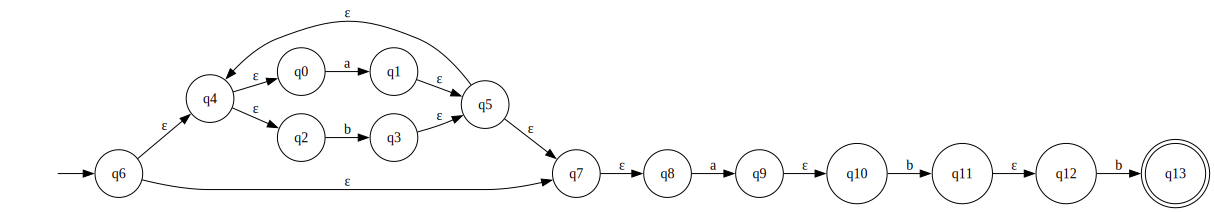

DFA for (a|b)*abb


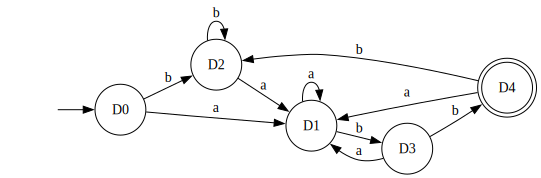

In [112]:
from IPython.display import display

# And we can test our NFA -> DFA conversion here 🐢

regex = "(a|b)*abb"

nfa = nfa_from_regex(regex)

print(f"NFA for {regex}")
display(draw(nfa))

dfa = nfa_to_dfa(nfa)

print(f"DFA for {regex}")
display(draw(dfa))

## 3. Minimización (Grupos Consistentes)
Basado en el Algoritmo de Equivalencia de Estados.
### Tarea 3.1: Partición Inicial
Divide los estados del AFD en dos grupos: finales y no finales.

In [113]:
type Partitions = tuple[set[State], set[State]]

def get_initial_partition(dfa_states_list: set[State]) -> Partitions:
    accepting: set[State] = set()
    non_accepting: set[State] = set()

    for state in dfa_states_list:
        if state.is_accepting:
            accepting.add(state)
        else:
            non_accepting.add(state)

    return (accepting, non_accepting)

## Tarea 3.2: Refinamiento de Grupos
Un grupo debe dividirse si sus estados transitan a grupos diferentes bajo el mismo símbolo.

In [114]:
def refine(partition: Partitions, alphabet: list[str]) -> tuple[Partitions, bool]:
    """
    Intenta dividir los grupos actuales de la partición.

    Algoritmo:
    1. Inicializar 'new_partition' como una lista vacía y 'changed' como False.
    2. Crear un mapeo 'state_to_group_idx' para asociar cada estado DFA a su índice de grupo actual.
    3. Para cada grupo en la 'partition' actual:
        a. Inicializar 'subgroup_candidates' como un diccionario vacío.
        b. Para cada estado dentro del grupo actual:
            i. Construir una 'signature' para el estado: una tupla de los índices de los grupos a los que transita el estado para cada símbolo del alfabeto (o None si no hay transición).
            ii. Añadir el estado a 'subgroup_candidates' bajo su 'signature'.
        c. Si el número de subgrupos generados es mayor que 1, establecer 'changed' en True.
        d. Añadir todos los subgrupos (valores de 'subgroup_candidates') a 'new_partition'.
    4. Devolver (new_partition, changed).
    """

    # This function is designed to be called until the changed result is False
    new_partition = []
    changed = False

    # maps (state -> group index)
    state_to_group_idx = {}
    for idx, group in enumerate(partition):
        for state in group:
            state_to_group_idx[state] = idx

    # For each group in the current partition, check whether all states
    # behave the same under all symbols
    for group in partition:

        # maps signature (transition behavior) -> set of states with that signature
        subgroup_candidates = {}

        # Compute a "signature" for every state in the group
        # The signature describes which partition group the state transitions to for
        # each symbol in the alphabet.
        #
        # - states with identical signatures remain together.
        # - states with different signatures must be separated.
        for state in group:

            signature = []

            for symbol in alphabet:
                target = None

                # Find the transition for this symbol
                for to, sym in state.transitions:
                    if sym == symbol:
                        target = to
                        break

                # no transition is represented as None
                if target is None:
                    signature.append(None)
                else:
                    signature.append(state_to_group_idx[target])

            # make it serializable
            signature = tuple(signature)

            # Group states by their signature
            subgroup_candidates.setdefault(signature, set()).add(state)

        # If more than one subgroup was created, the we have a split!!
        if len(subgroup_candidates) > 1:
            changed = True

        # Add finally we all resulting subgroups to the new partition
        new_partition.extend(subgroup_candidates.values())

    return new_partition, changed


Finalmente creamos una función que unifique todos estos pasos:

- Recibe un DFA
- Obtiene su alfabeto
- Crea la partición inicial
- La refina hasta llegar al último nivel de equivalencia

In [115]:
# Reference algorithm:
# https://www.youtube.com/watch?v=0XaGAkY09Wc&list=PLBlnK6fEyqRhayMdYyMlzk0C0j_FsF6j9&index=2

def minimize_dfa(dfa: NFA) -> NFA:
    """
    Minimiza un DFA usando el algoritmo de refinamiento de particiones.

    Retorna un nuevo DFA con el número mínimo de estados que reconoce
    el mismo lenguaje que el DFA de entrada.
    """
    # 1. Extraer el alfabeto del DFA
    alphabet = dfa.get_alphabet()

    # 2. Crear partición inicial: {estados aceptantes}, {estados no aceptantes}
    partition = list(get_initial_partition(dfa.states))

    # 3. Refinar hasta que no haya más cambios (last equivalence level)
    changed = True
    while changed:
        partition, changed = refine(partition, alphabet)

    # 4. Finalmente, construimos el DFA minimizado
    # Crear un mapeo de cada estado original a su índice de grupo
    state_to_group = {}
    for idx, group in enumerate(partition):
        for state in group:
            state_to_group[state] = idx

    # Y creamos un nuevo estado por cada grupo de equivalencia
    new_states = [State(f"M{i}") for i in range(len(partition))]

    # Establecemos el estado de aceptación y transiciones para cada nuevo estado
    for idx, group in enumerate(partition):
        # Mismo criterio de aceptación para los grupos
        new_states[idx].is_accepting = any(s.is_accepting for s in group)

        # Cualquier estado nos sirve para obtener las transiciones
        representative = next(iter(group))

        for to_state, symbol in representative.transitions:
            target_group_idx = state_to_group[to_state]
            new_states[idx].add_transition(new_states[target_group_idx], symbol)

    # Y lo devolvemos como objeto autómata
    minimized = NFA()
    minimized.start_state = new_states[state_to_group[dfa.start_state]]
    minimized.states = set(new_states)

    return minimized

## 4. Reto Final
Genera el AFD para la expresión regular (a|b)*abb. Visualiza el AFN generado.Ejecuta tu conversión a AFD y visualízalo. Ejecuta tu minimización y muestra el resultado final.

1. NFA for: (a|b)*abb (14 states)


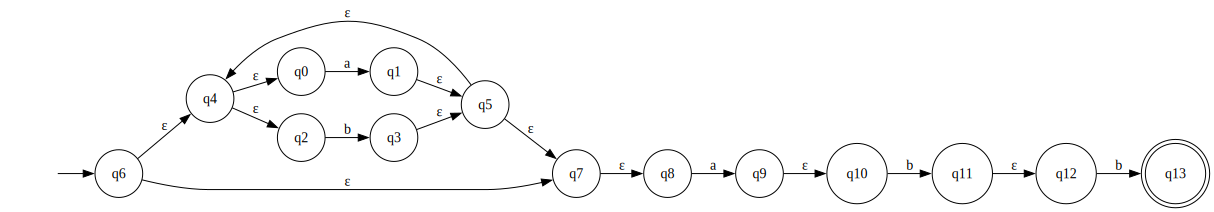

2. NFA -> DFA: 5 states


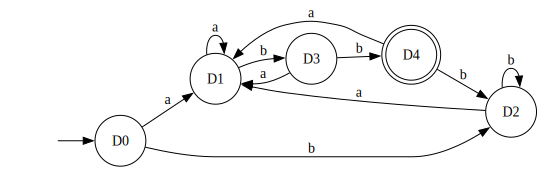

3. Minimized DFA: 4 states


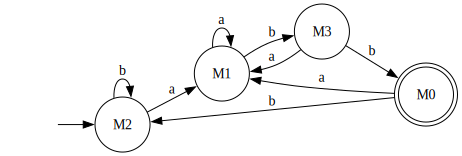

In [120]:
# Pipeline completo: Regex → NFA → DFA → DFA Minimizado

regex_final = '(a|b)*abb'

# 1. Generar NFA para la expresión regular
afn_final = nfa_from_regex(regex_final)
print(f"1. NFA for: {regex_final} ({len(afn_final.states)} states)")
display(draw(afn_final))

# 2. Convertir NFA a DFA
afd_final = nfa_to_dfa(afn_final)
print(f"2. NFA -> DFA: {len(afd_final.states)} states")
display(draw(afd_final))

# 3. Minimizar el DFA resultante
afd_minimizado = minimize_dfa(afd_final)
print(f"3. Minimized DFA: {len(afd_minimizado.states)} states")
display(draw(afd_minimizado))